In [60]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [61]:
import os

# If the kernel started from the plots/ subdirectory, move up to the base directory.
if os.path.basename(os.getcwd()) == 'plots':
    os.chdir('..')
#print('Working directory:', os.getcwd())

from coffea.util import load
from plots import hep_plot as hplot
from plots.hep_plot import CMS_COLORS



In [62]:
output = load('./outputs/dy/ZPrime4000_Local_2024.coffea')

In [63]:
era = 2024


[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7cde9d746260>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

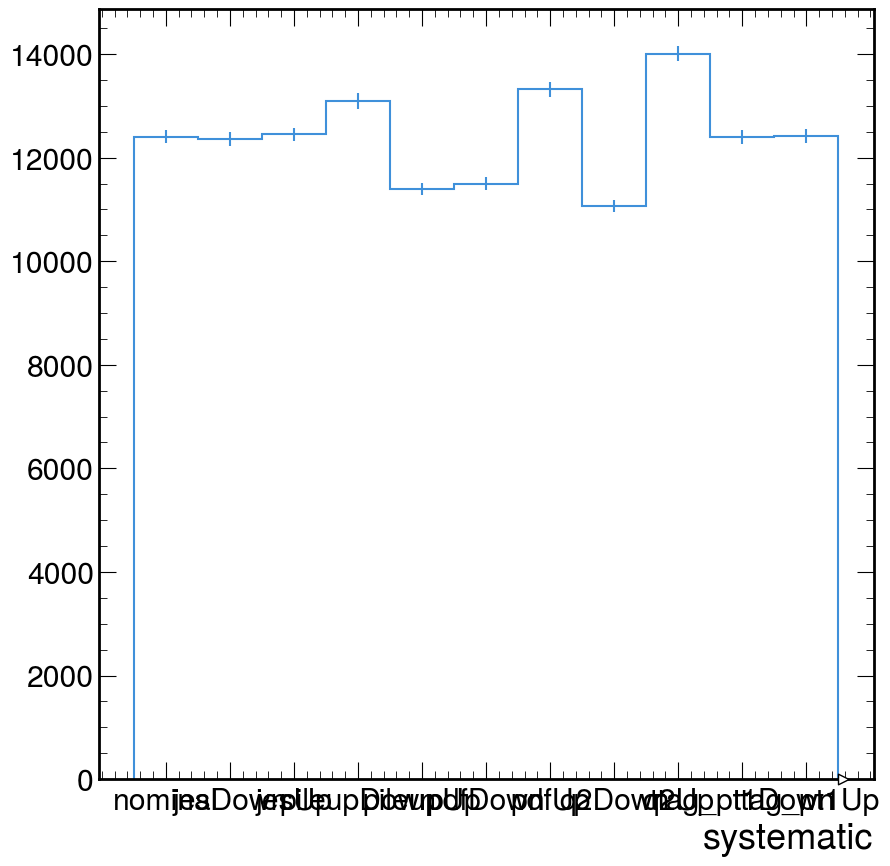

In [64]:
output['jetmsd'].project('systematic').plot()

In [77]:
output['ttbarmass'].project('systematic')

Hist(StrCategory(['nominal', 'jesDown', 'jesUp', 'pileupDown', 'pileupUp', 'pdfDown', 'pdfUp', 'q2Down', 'q2Up', 'ttag_pt1Down', 'ttag_pt1Up'], name='systematic'), storage=Weight()) # Sum: WeightedSum(value=136411, variance=200027) (WeightedSum(value=186043, variance=271668) with flow)

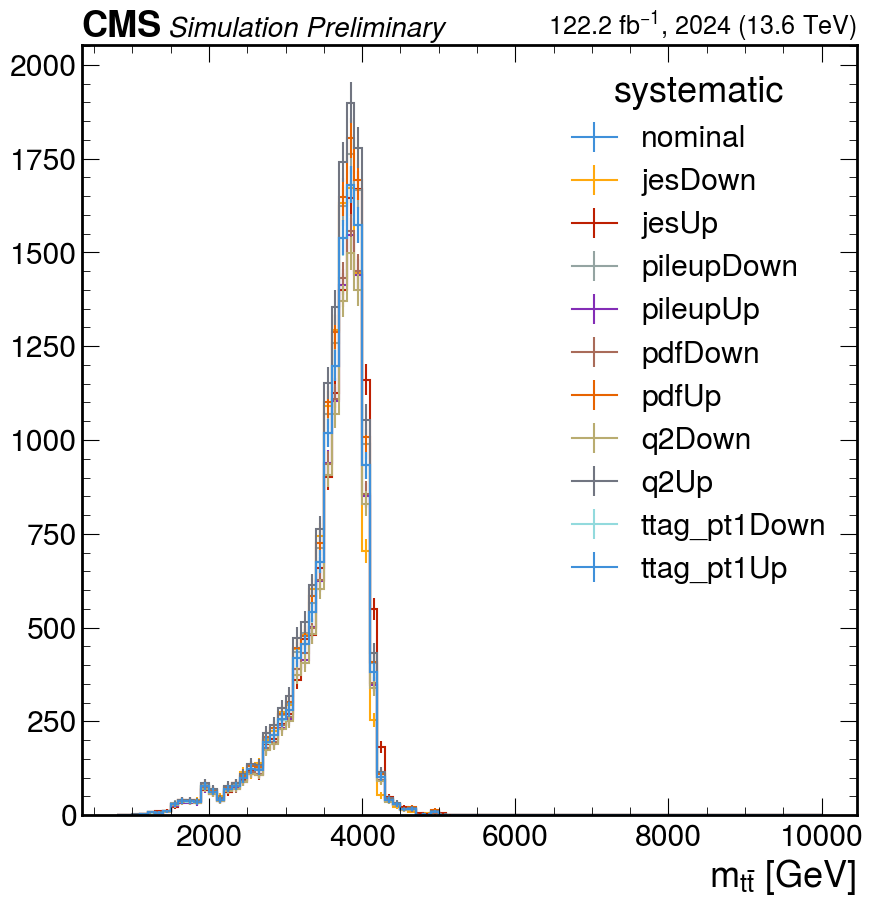

In [65]:
hplot.setup(era = 2024)
output['ttbarmass'].project('systematic', 'ttbarmass').plot()
hplot.quick_label()

In [81]:
import mplhep as mh
import matplotlib.pyplot as plt

def plot_systematic(syst_name, h_key, hist_axis, xlabel=''):
    """Plot nominal vs Up/Down variation for a given systematic."""
    hplot.setup(era=2024)
    h_nom  = output[h_key].project('systematic', hist_axis)['nominal', ...]
    h_up   = output[h_key].project('systematic', hist_axis)[f'{syst_name}Up', ...]
    h_down = output[h_key].project('systematic', hist_axis)[f'{syst_name}Down', ...]

    fig, (ax_main, ax_comp) = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [3, 1]})
    h_nom.plot( density=False, ax=ax_main, color='k',           label='Nominal')
    h_up.plot(  density=False, ax=ax_main, color=CMS_COLORS[0], label=f'{syst_name} Up')
    h_down.plot(density=False, ax=ax_main, color=CMS_COLORS[4], label=f'{syst_name} Down')
    ax_main.legend()
    #ax_main.set_title(f'{h_key}  —  {syst_name}')
    hplot.quick_label(data=False, ax=ax_main, xlabel='', ylabel='# Events')

    mh.comp.comparison(
        h_nom, h_up,
        ax=ax_comp, comparison='ratio',
        h1_label='Nominal', h2_label=f'{syst_name} Up',
        color=CMS_COLORS[0],
    )
    mh.comp.comparison(
        h_nom, h_down,
        ax=ax_comp, comparison='ratio',
        h1_label='Nominal', h2_label=f'{syst_name} Down',
        color=CMS_COLORS[4],
        xlabel=xlabel, comparison_ylim=(0, 2),
    )
    plt.tight_layout()
    plt.show()


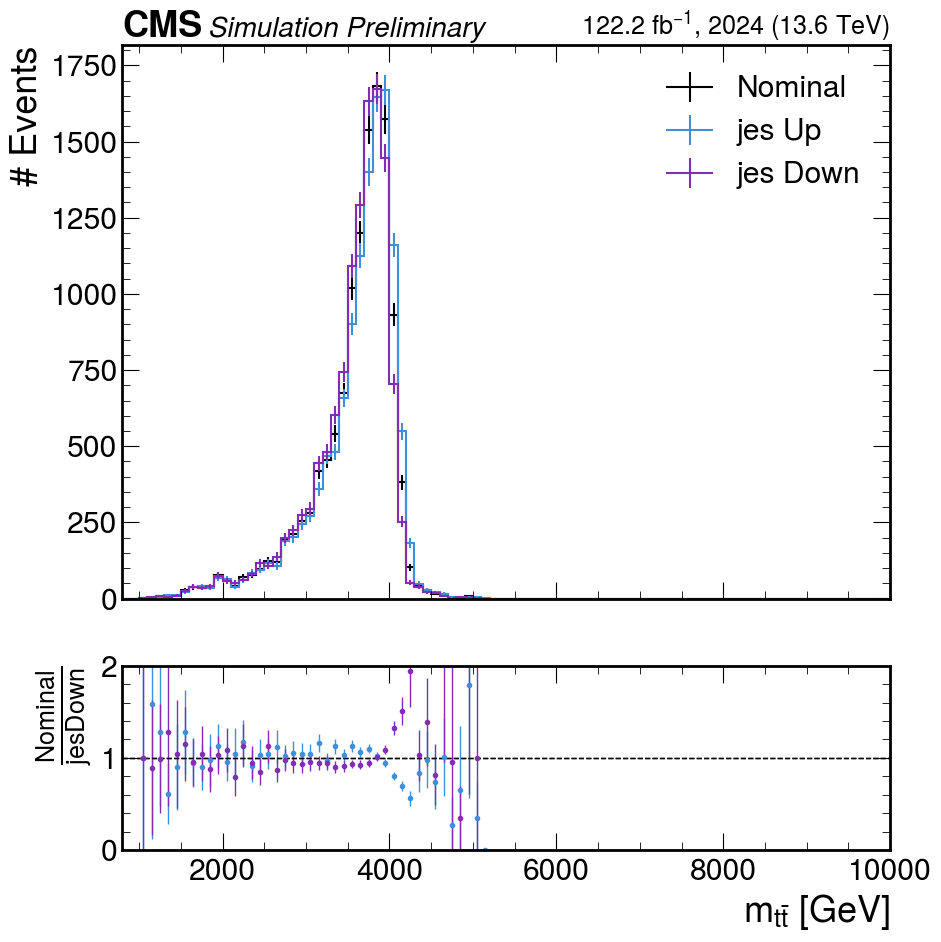

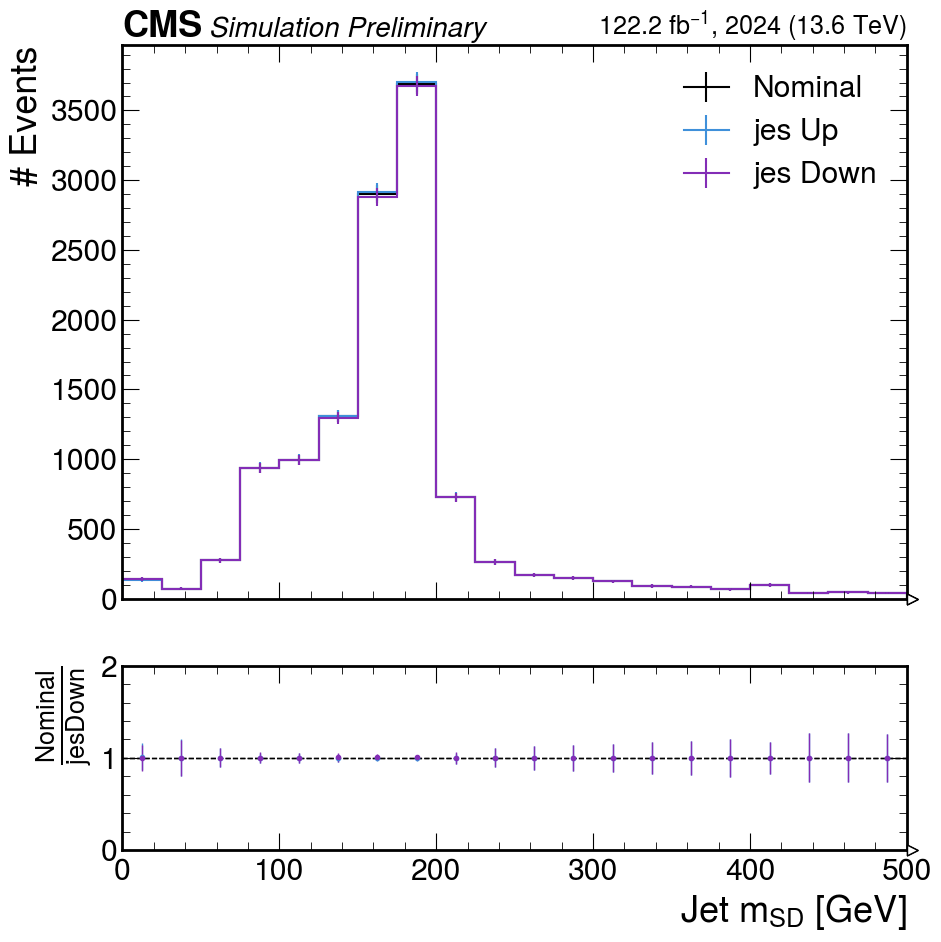

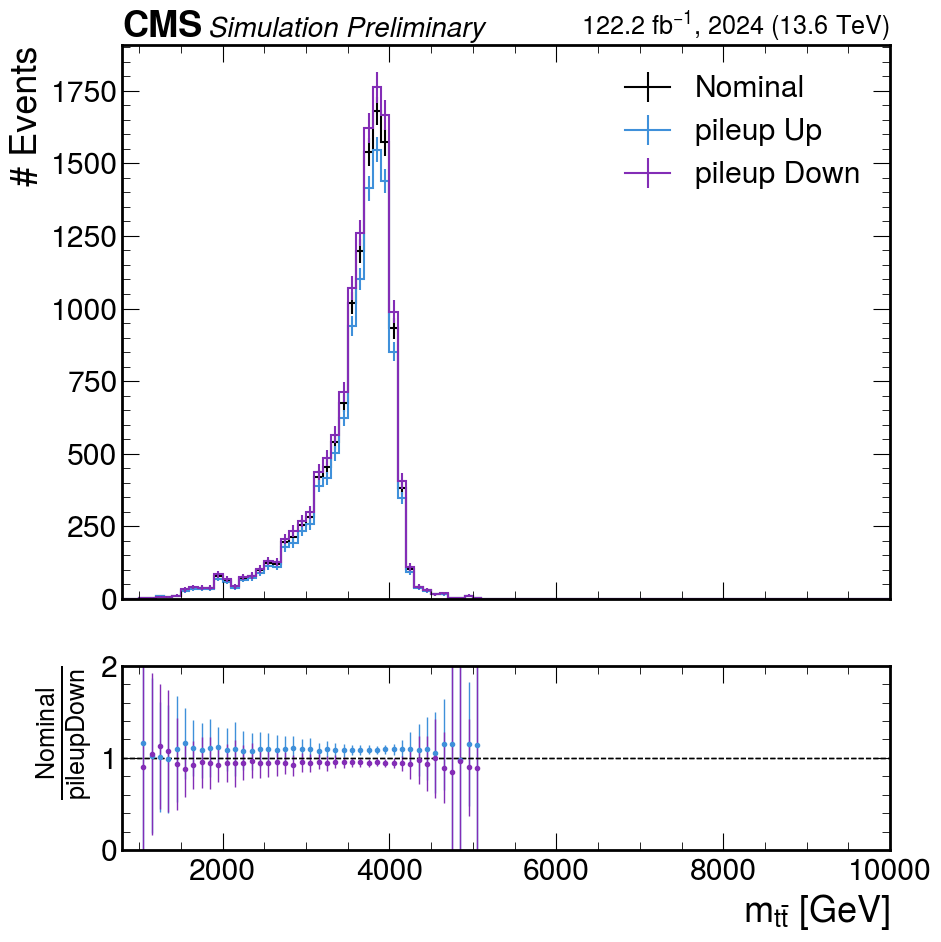

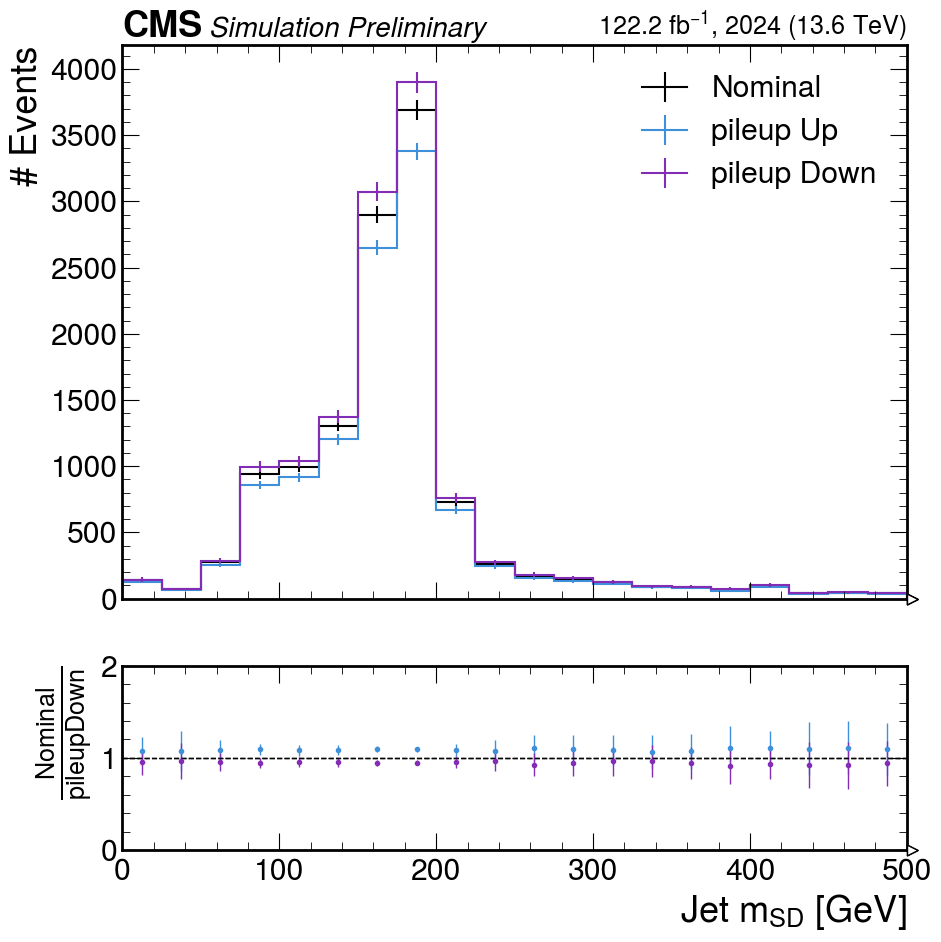

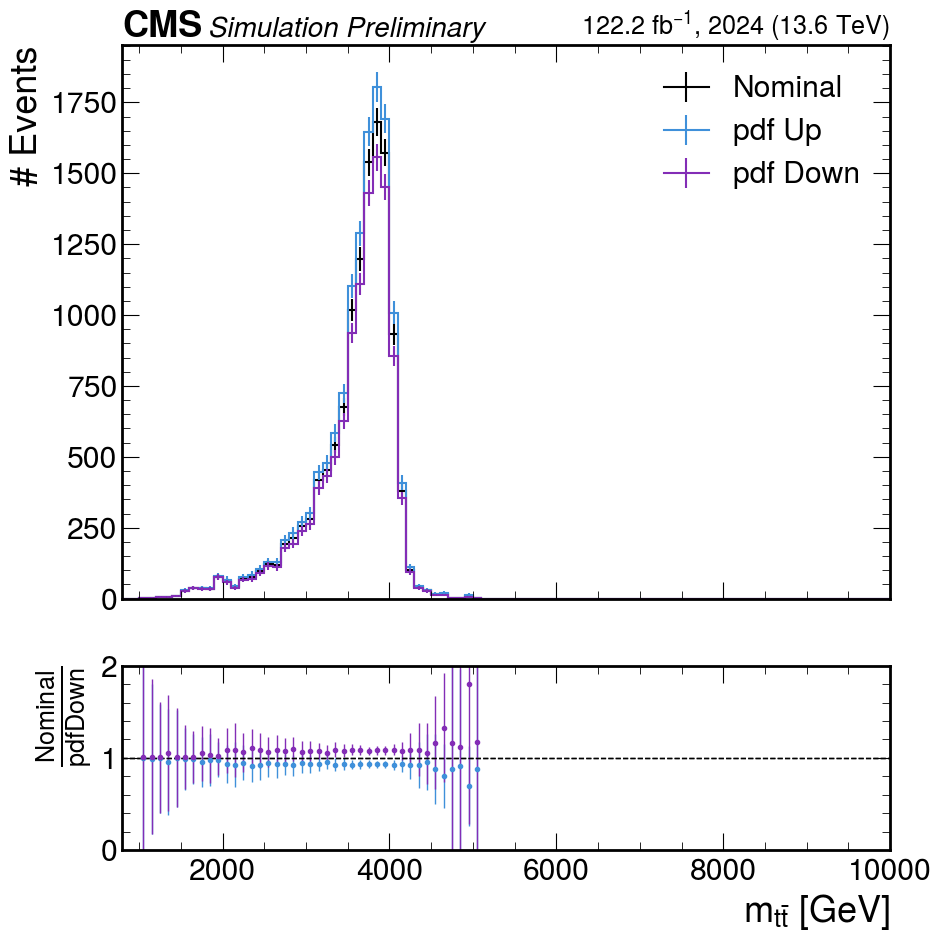

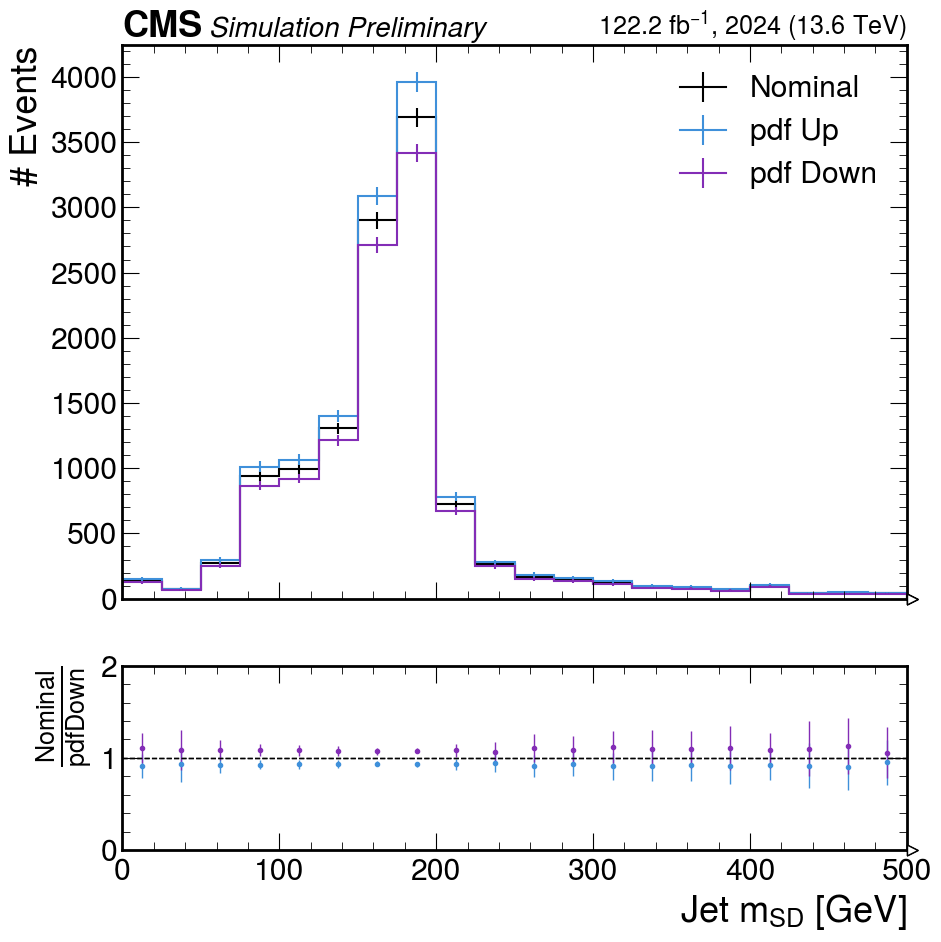

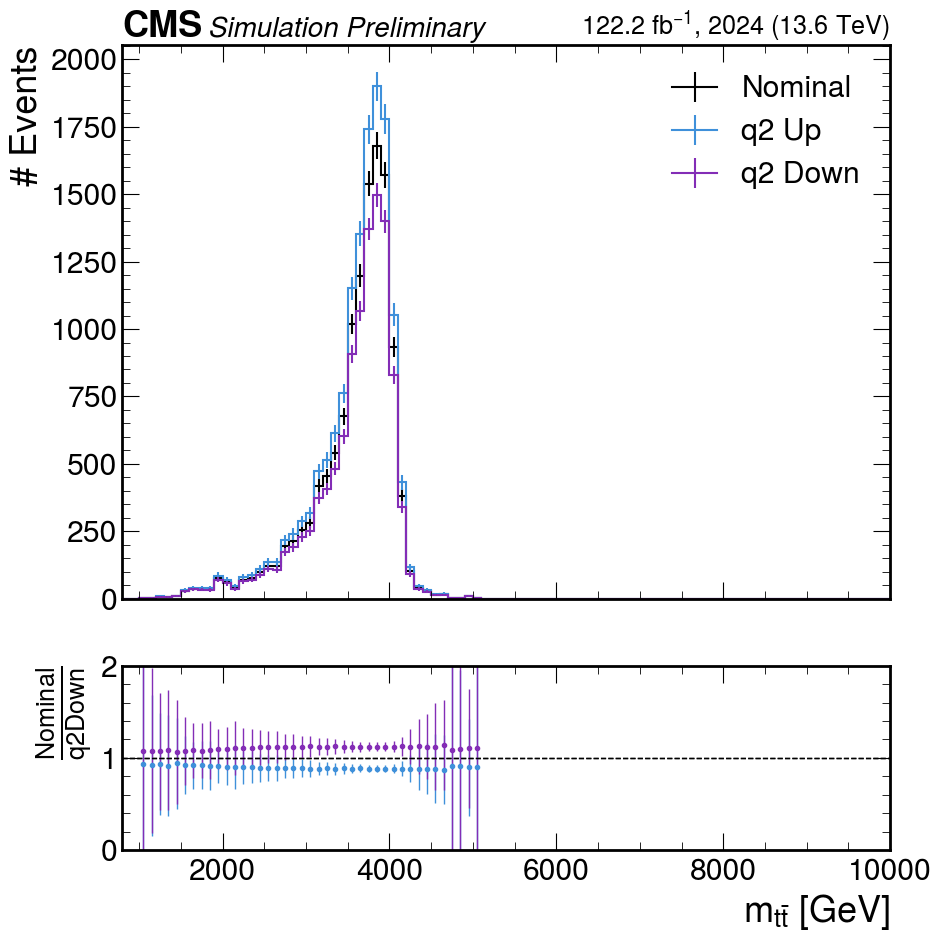

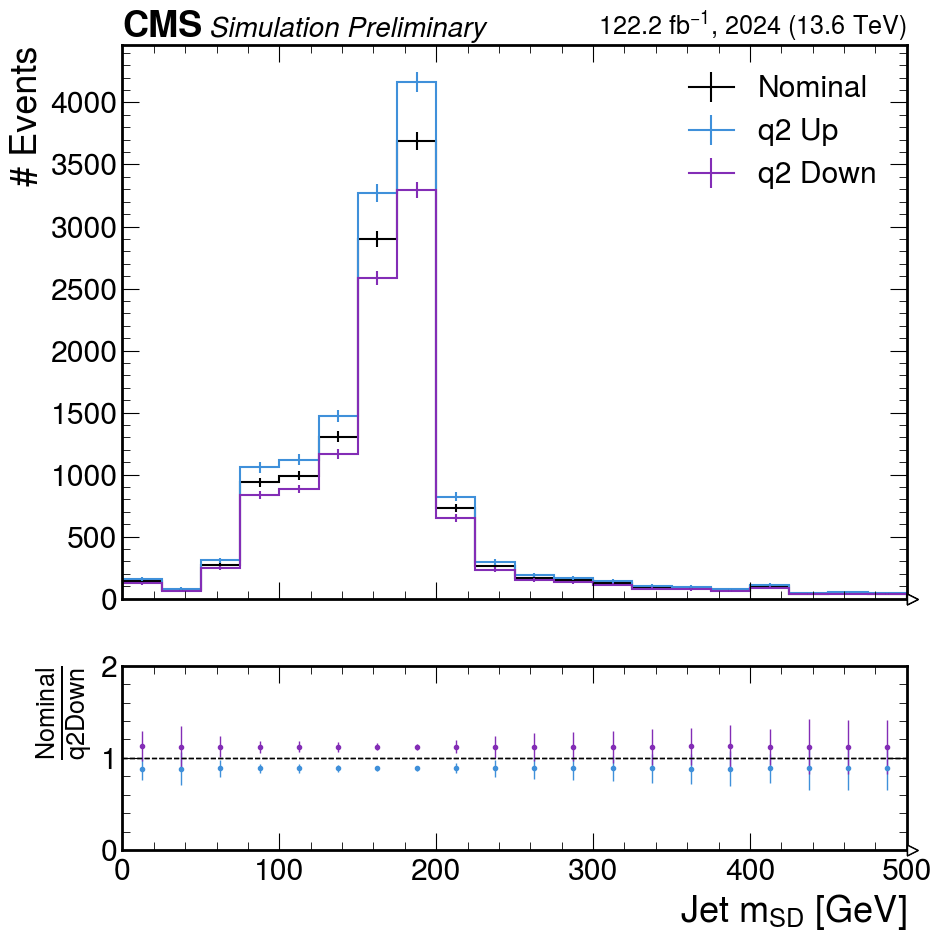

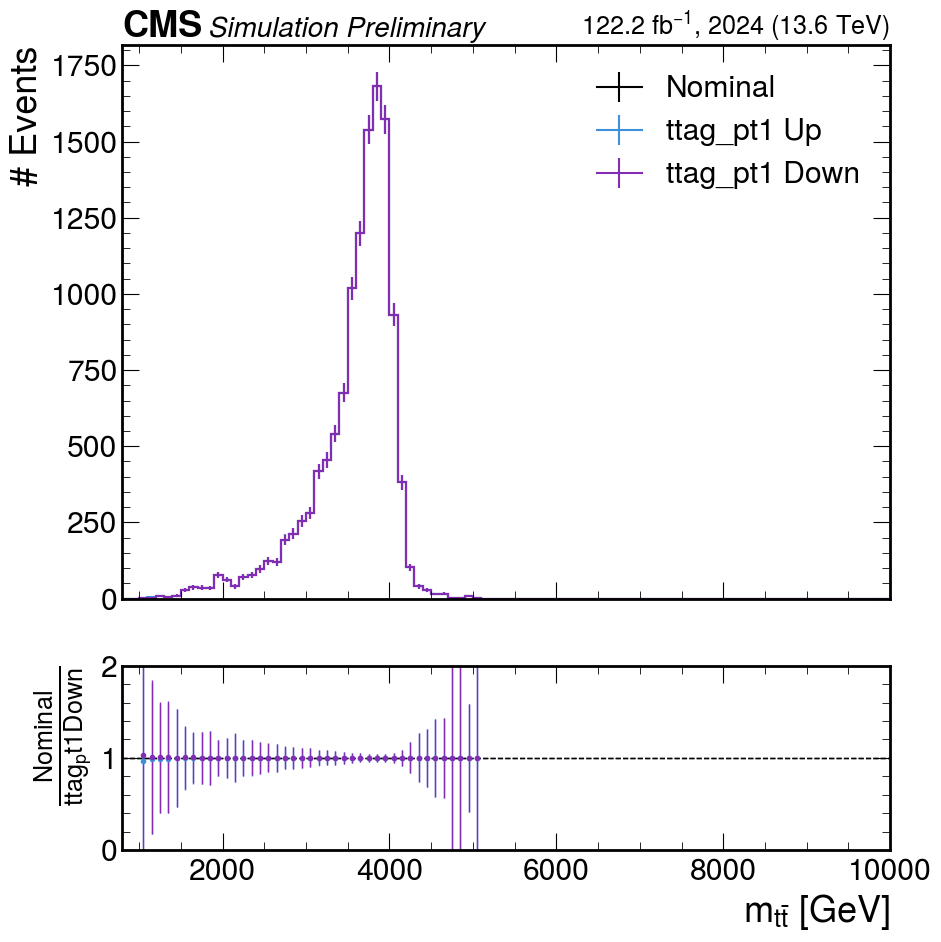

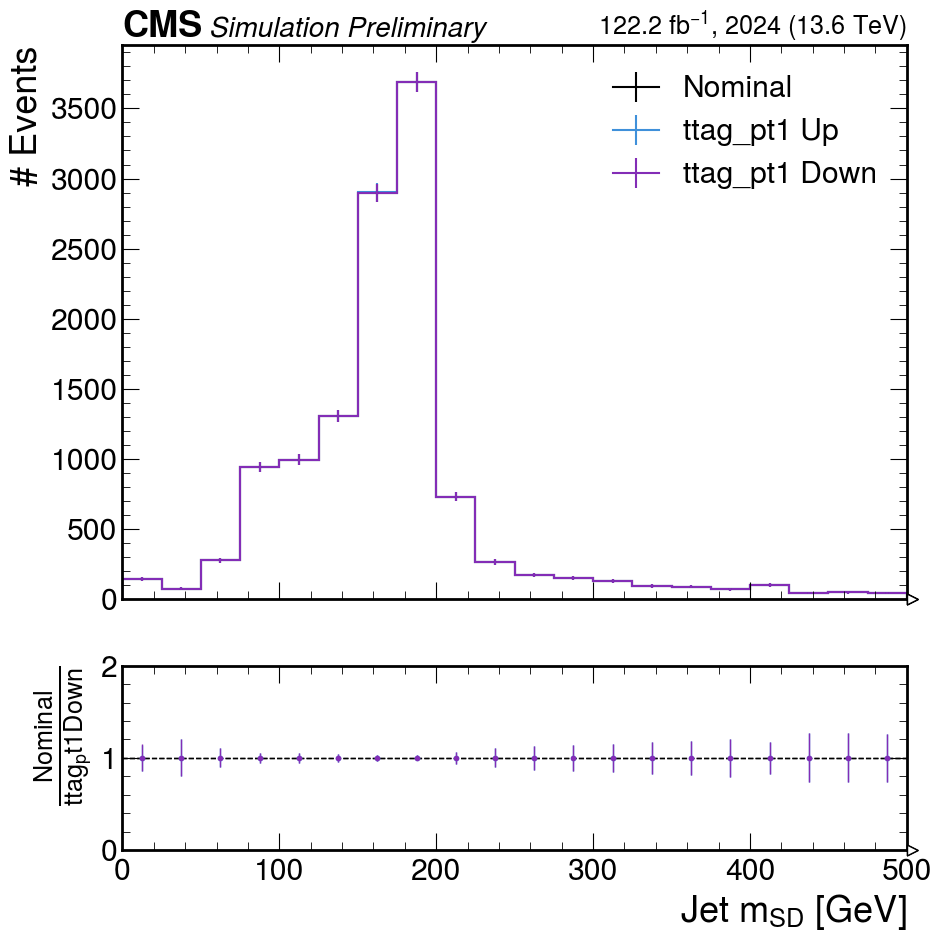

In [82]:
systematics = ['jes', 'pileup', 'pdf', 'q2', 'ttag_pt1']

for syst in systematics:
    plot_systematic(syst, 'ttbarmass', 'ttbarmass', xlabel=r'$m_{t\bar{t}}$ [GeV]')
    plot_systematic(syst, 'jetmsd',    'jetmass',   xlabel=r'Jet $m_{SD}$ [GeV]')
